# 🔍 Luminância v3 — Comparação de Classificadores
Reutiliza as features salvas em cache (`cache_lum_v3/`) para testar múltiplos algoritmos.

**Features:** 77 dimensões extraídas de luminância (PCA, FFT, HOG, Sobel, blocos 4×4)  
**Labels:** 0 = Real | 1 = IA

## Bloco 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# Classificadores
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## Bloco 2 — Carregar Features do Cache

In [2]:
CACHE_DIR = Path('./cache_lum_v3')

# Verifica arquivos disponíveis
print('📦 Arquivos no cache:')
for f in sorted(CACHE_DIR.glob('*.npy')):
    data = np.load(f)
    print(f'   {f.name}: shape={data.shape}, dtype={data.dtype}')

# Carrega os splits
X_train = np.load(CACHE_DIR / 'train_X.npy')
y_train = np.load(CACHE_DIR / 'train_y.npy')
X_val   = np.load(CACHE_DIR / 'val_X.npy')
y_val   = np.load(CACHE_DIR / 'val_y.npy')
X_test  = np.load(CACHE_DIR / 'test_X.npy')
y_test  = np.load(CACHE_DIR / 'test_y.npy')

# Para treino aqui, juntamos train + val (o test continua intocado)
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

print(f'\n📐 Train+Val : {X_train_full.shape} | Test: {X_test.shape}')
print(f'📊 Train+Val — Real: {(y_train_full==0).sum():,} | Fake: {(y_train_full==1).sum():,}')
print(f'📊 Test      — Real: {(y_test==0).sum():,}       | Fake: {(y_test==1).sum():,}')

📦 Arquivos no cache:
   test_X.npy: shape=(11997, 77), dtype=float32
   test_y.npy: shape=(11997,), dtype=int8
   train_X.npy: shape=(81595, 77), dtype=float32
   train_y.npy: shape=(81595,), dtype=int8
   val_X.npy: shape=(7198, 77), dtype=float32
   val_y.npy: shape=(7198,), dtype=int8

📐 Train+Val : (88793, 77) | Test: (11997, 77)
📊 Train+Val — Real: 44,393 | Fake: 44,400
📊 Test      — Real: 5,997       | Fake: 6,000


## Bloco 3 — Normalização

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_full)
X_test_s  = scaler.transform(X_test)

print(f'✅ Normalização aplicada')
print(f'   NaN — train: {np.isnan(X_train_s).sum()} | test: {np.isnan(X_test_s).sum()}')

✅ Normalização aplicada
   NaN — train: 0 | test: 0


## Bloco 4 — Definição dos Classificadores

In [4]:
# Proporção das classes para balanceamento
n_real = (y_train_full == 0).sum()
n_fake = (y_train_full == 1).sum()
scale_pw = n_real / n_fake

CLASSIFICADORES = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        class_weight='balanced', probability=True, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        solver='lbfgs', random_state=42, n_jobs=-1
    ),
    'MLP (Neural Net)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        max_iter=300, early_stopping=True, validation_fraction=0.1,
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    'KNN (k=7)': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': GaussianNB(),
}

print(f'✅ {len(CLASSIFICADORES)} classificadores definidos')
for nome in CLASSIFICADORES:
    print(f'   • {nome}')

✅ 11 classificadores definidos
   • XGBoost
   • Random Forest
   • Gradient Boosting
   • Extra Trees
   • SVM (RBF)
   • Logistic Regression
   • MLP (Neural Net)
   • AdaBoost
   • KNN (k=7)
   • Decision Tree
   • Naive Bayes


## Bloco 5 — Treinamento e Avaliação

In [5]:
resultados = []

for nome, clf in CLASSIFICADORES.items():
    print(f'⚙️  Treinando {nome}...')
    t0 = time.time()

    clf.fit(X_train_s, y_train_full)
    y_pred = clf.predict(X_test_s)

    # AUC-ROC (requer predict_proba ou decision_function)
    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test_s)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_proba = clf.decision_function(X_test_s)
    else:
        y_proba = y_pred.astype(float)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    tempo = time.time() - t0

    resultados.append({
        'nome': nome, 'clf': clf,
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'f1': f1, 'auc': auc, 'tempo': tempo
    })

    print(f'   ✅ Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | ⏱️ {tempo:.1f}s')

# Ordenar por acurácia
resultados.sort(key=lambda x: x['accuracy'], reverse=True)

print('\n' + '='*65)
print(f'{"Classificador":<22} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"Tempo":>8}')
print('='*65)
for r in resultados:
    print(f"{r['nome']:<22} {r['accuracy']:>10.4f} {r['f1']:>8.4f} {r['auc']:>10.4f} {r['tempo']:>7.1f}s")
print('='*65)

⚙️  Treinando XGBoost...
   ✅ Acc=0.8386 | F1=0.8421 | AUC=0.9161 | ⏱️ 7.1s
⚙️  Treinando Random Forest...
   ✅ Acc=0.8275 | F1=0.8309 | AUC=0.9076 | ⏱️ 18.2s
⚙️  Treinando Gradient Boosting...
   ✅ Acc=0.8276 | F1=0.8319 | AUC=0.9089 | ⏱️ 458.6s
⚙️  Treinando Extra Trees...
   ✅ Acc=0.8163 | F1=0.8231 | AUC=0.8988 | ⏱️ 4.1s
⚙️  Treinando SVM (RBF)...
   ✅ Acc=0.8356 | F1=0.8376 | AUC=0.9149 | ⏱️ 2890.3s
⚙️  Treinando Logistic Regression...
   ✅ Acc=0.8009 | F1=0.8025 | AUC=0.8716 | ⏱️ 1.9s
⚙️  Treinando MLP (Neural Net)...
   ✅ Acc=0.8156 | F1=0.8156 | AUC=0.8878 | ⏱️ 101.4s
⚙️  Treinando AdaBoost...
   ✅ Acc=0.7743 | F1=0.7920 | AUC=0.8517 | ⏱️ 139.5s
⚙️  Treinando KNN (k=7)...
   ✅ Acc=0.7679 | F1=0.7781 | AUC=0.8437 | ⏱️ 1.5s
⚙️  Treinando Decision Tree...
   ✅ Acc=0.7854 | F1=0.7945 | AUC=0.8456 | ⏱️ 5.6s
⚙️  Treinando Naive Bayes...
   ✅ Acc=0.6685 | F1=0.7327 | AUC=0.7324 | ⏱️ 0.0s

Classificador            Accuracy       F1    AUC-ROC    Tempo
XGBoost                    0.8386 

## Bloco 6 — Matrizes de Confusão (todos os classificadores)

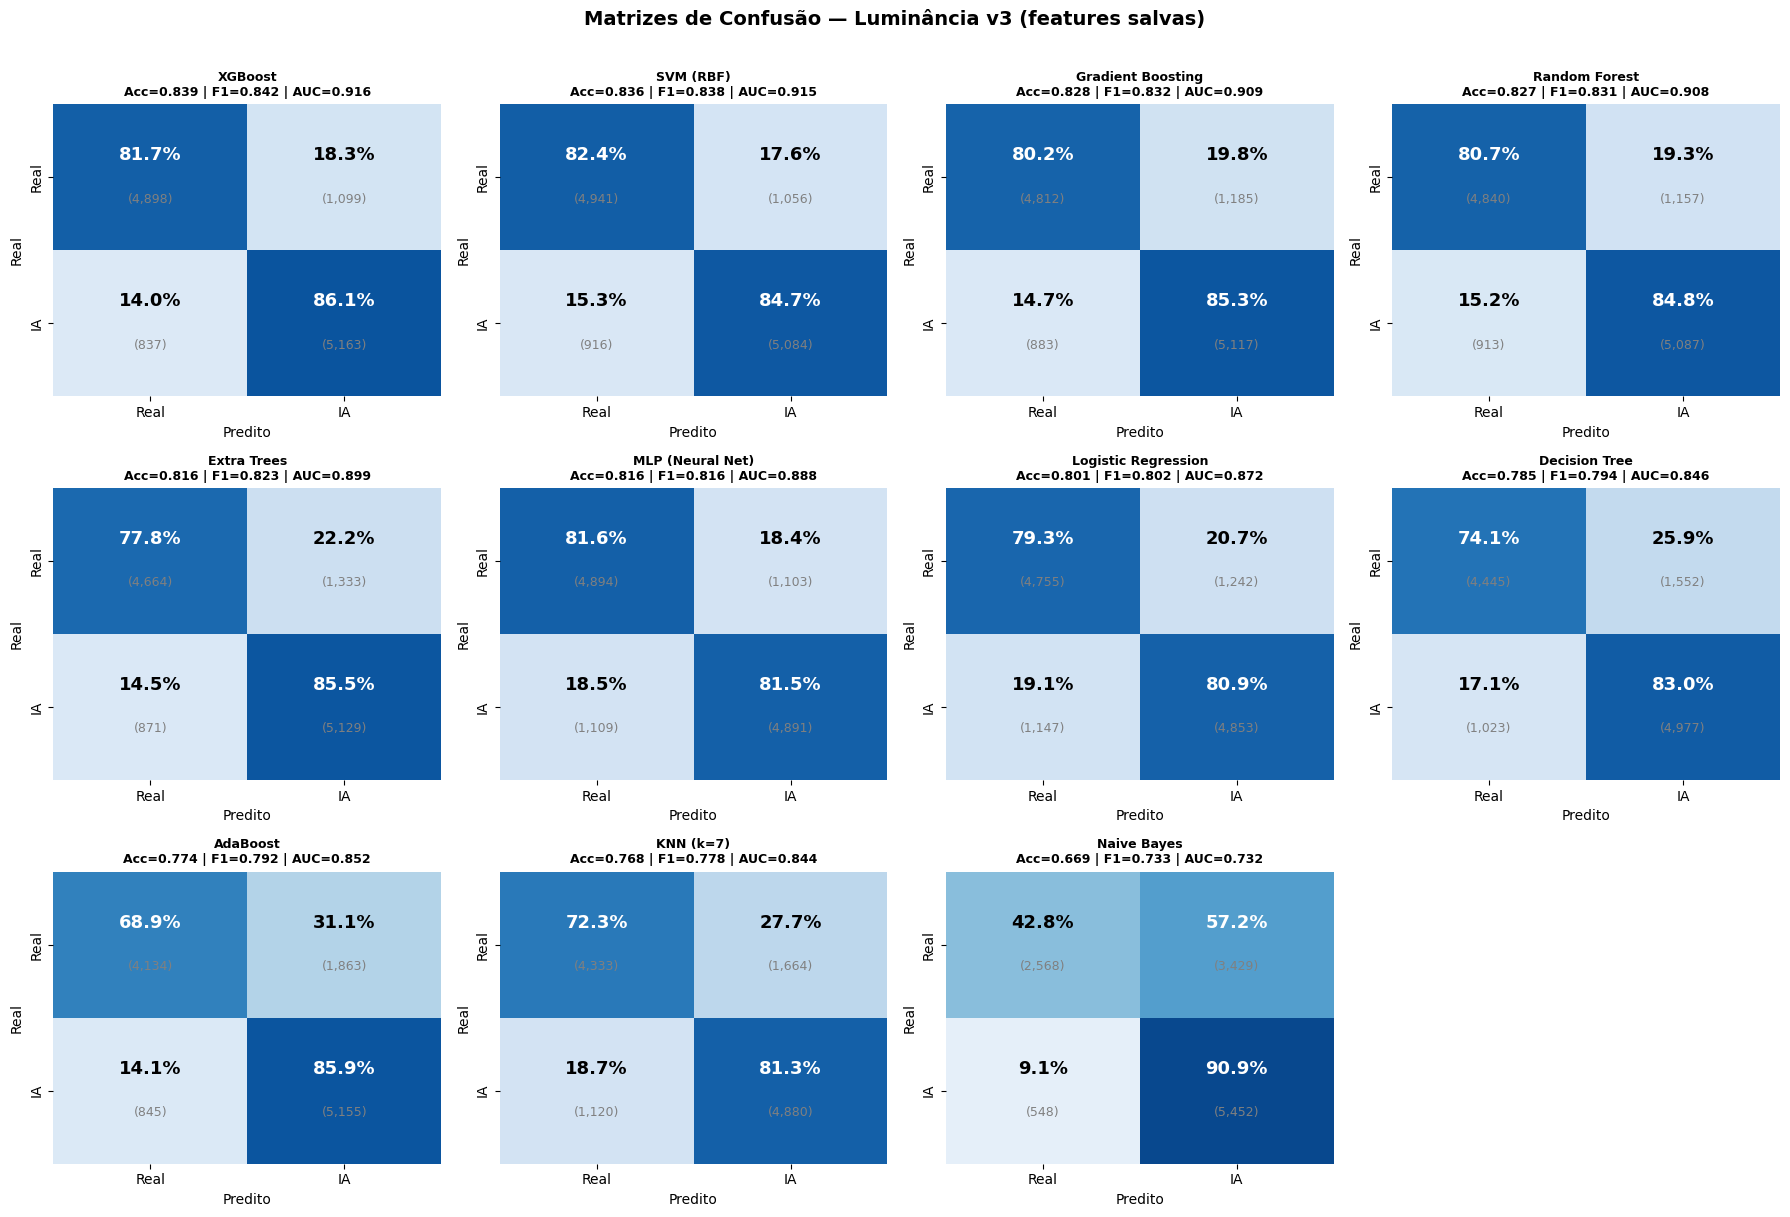

💾 Salvo: comparacao_matrizes_confusao.png


In [6]:
n_clf = len(resultados)
cols  = 4
rows  = (n_clf + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes_flat = axes.flatten()

for idx, r in enumerate(resultados):
    ax  = axes_flat[idx]
    cm  = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=False, fmt='.1f', cmap='Blues', ax=ax,
        xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
        vmin=0, vmax=100, cbar=False
    )

    # Anotações com % e contagem absoluta
    for i in range(2):
        for j in range(2):
            cor = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j + 0.5, i + 0.35, f'{cm_pct[i,j]:.1f}%',
                    ha='center', va='center', fontsize=13, fontweight='bold', color=cor)
            ax.text(j + 0.5, i + 0.65, f'({cm[i,j]:,})',
                    ha='center', va='center', fontsize=9, color='gray')

    ax.set_title(
        f"{r['nome']}\nAcc={r['accuracy']:.3f} | F1={r['f1']:.3f} | AUC={r['auc']:.3f}",
        fontsize=9, fontweight='bold'
    )
    ax.set_ylabel('Real'); ax.set_xlabel('Predito')

# Ocultar subplots extras
for idx in range(n_clf, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrizes de Confusão — Luminância v3 (features salvas)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparacao_matrizes_confusao.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Salvo: comparacao_matrizes_confusao.png')

## Bloco 7 — Gráfico de Ranking de Acurácia

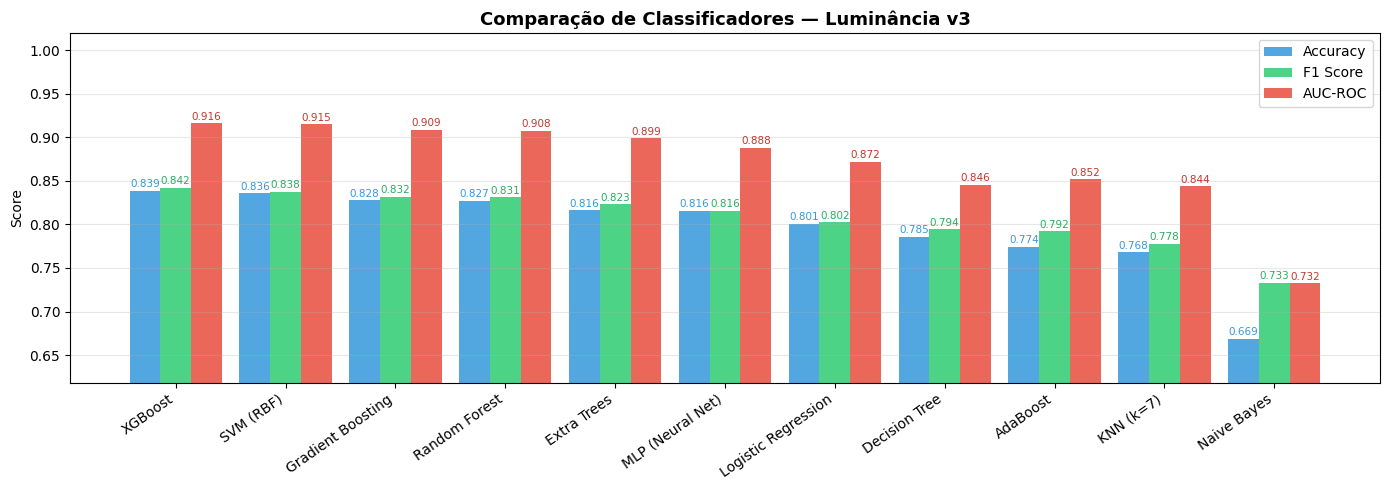

💾 Salvo: comparacao_ranking.png


In [7]:
nomes    = [r['nome'] for r in resultados]
accs     = [r['accuracy'] for r in resultados]
f1s      = [r['f1'] for r in resultados]
aucs     = [r['auc'] for r in resultados]

x = np.arange(len(nomes))
w = 0.28

fig, ax = plt.subplots(figsize=(14, 5))

bars1 = ax.bar(x - w, accs, w, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x,     f1s,  w, label='F1 Score', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + w, aucs, w, label='AUC-ROC',  color='#e74c3c', alpha=0.85)

# Valores no topo
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color='#3498db')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color='#27ae60')
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=35, ha='right', fontsize=10)
ax.set_ylim(min(min(accs), min(f1s), min(aucs)) - 0.05, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de Classificadores — Luminância v3', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig('comparacao_ranking.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Salvo: comparacao_ranking.png')

## Bloco 8 — Relatório Detalhado do Melhor Classificador

In [8]:
melhor = resultados[0]
print(f'🏆 Melhor classificador: {melhor["nome"]}')
print(f'   Accuracy : {melhor["accuracy"]:.4f}')
print(f'   F1 Score : {melhor["f1"]:.4f}')
print(f'   AUC-ROC  : {melhor["auc"]:.4f}')
print(f'   Tempo    : {melhor["tempo"]:.1f}s')
print()
print(classification_report(y_test, melhor['y_pred'], target_names=['Real', 'IA']))

cm = confusion_matrix(y_test, melhor['y_pred'])
tn, fp, fn, tp = cm.ravel()
print(f'\n🔬 Análise de erros ({melhor["nome"]}):')
print(f'   Falsos Positivos (Real → IA): {fp:,} ({fp/(tn+fp)*100:.1f}%)')
print(f'   Falsos Negativos (IA → Real): {fn:,} ({fn/(fn+tp)*100:.1f}%)')

🏆 Melhor classificador: XGBoost
   Accuracy : 0.8386
   F1 Score : 0.8421
   AUC-ROC  : 0.9161
   Tempo    : 7.1s

              precision    recall  f1-score   support

        Real       0.85      0.82      0.83      5997
          IA       0.82      0.86      0.84      6000

    accuracy                           0.84     11997
   macro avg       0.84      0.84      0.84     11997
weighted avg       0.84      0.84      0.84     11997


🔬 Análise de erros (XGBoost):
   Falsos Positivos (Real → IA): 1,099 (18.3%)
   Falsos Negativos (IA → Real): 837 (14.0%)


## Bloco 9 — Tabela Resumo Final

In [9]:
print('\n' + '='*72)
print(f'{'#':>3}  {"Classificador":<22} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"Tempo":>8}')
print('='*72)
for i, r in enumerate(resultados, 1):
    medal = ['🥇', '🥈', '🥉'][i-1] if i <= 3 else f'#{i} '
    print(f'{medal:>4} {r["nome"]:<22} {r["accuracy"]:>10.4f} {r["f1"]:>8.4f} {r["auc"]:>10.4f} {r["tempo"]:>7.1f}s')
print('='*72)
print(f'\n✅ Avaliação concluída! {len(resultados)} classificadores testados no conjunto de teste.')


  #  Classificador            Accuracy       F1    AUC-ROC    Tempo
   🥇 XGBoost                    0.8386   0.8421     0.9161     7.1s
   🥈 SVM (RBF)                  0.8356   0.8376     0.9149  2890.3s
   🥉 Gradient Boosting          0.8276   0.8319     0.9089   458.6s
 #4  Random Forest              0.8275   0.8309     0.9076    18.2s
 #5  Extra Trees                0.8163   0.8231     0.8988     4.1s
 #6  MLP (Neural Net)           0.8156   0.8156     0.8878   101.4s
 #7  Logistic Regression        0.8009   0.8025     0.8716     1.9s
 #8  Decision Tree              0.7854   0.7945     0.8456     5.6s
 #9  AdaBoost                   0.7743   0.7920     0.8517   139.5s
#10  KNN (k=7)                  0.7679   0.7781     0.8437     1.5s
#11  Naive Bayes                0.6685   0.7327     0.7324     0.0s

✅ Avaliação concluída! 11 classificadores testados no conjunto de teste.
